# HRRR extract

SAIL M1 site location:

- lat = 38.956158
- lon = -106.987854
- y=262, x=492

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import math as m

# from insolation import insolf # main package for terrain

# import pygrib # NOT required
from netCDF4 import Dataset
from osgeo import gdal, osr

import random

In [2]:
# DEM INFO
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

with Dataset(ERW_TOPO_FILE) as dem:
    sky_view_factor = dem['sky_view_factor'][:].astype(np.float64)
    dem = dem['dem'][:].astype(np.float64)

# Open single

In [3]:
import xarray as xr

dax = xr.open_dataset(
    f"{HRRR_DATA}hrrr.20220301/hrrr.t16z.wrfsfcf06.grib2",
    engine="cfgrib",
    filter_by_keys={
        'shortName': 'dswrf',      # variable name
        'typeOfLevel': 'surface'  # level type ['heightAboveGround']
    }

)

In [4]:
import numpy as np

lat0 = 38.956158
lon0 = -106.987854

# convert lon to 0–360 if necessary
if lon0 < 0:
    lon0 = lon0 + 360

# compute distance grid
dist = np.hypot(dax.latitude - lat0,
                dax.longitude - lon0)

# find the nearest grid point index
iy, ix = np.unravel_index(dist.argmin(), dist.shape)

# extract the time series
point_ts = dax.dswrf[iy, ix].compute()

print(point_ts)


<xarray.DataArray 'dswrf' ()> Size: 4B
array(586.8, dtype=float32)
Coordinates:
    time        datetime64[ns] 8B 2022-03-01T16:00:00
    step        timedelta64[ns] 8B 06:00:00
    surface     float64 8B 0.0
    latitude    float64 8B 38.95
    longitude   float64 8B 253.0
    valid_time  datetime64[ns] 8B 2022-03-01T22:00:00
Attributes: (12/34)
    GRIB_paramId:                             260087
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      407740
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                Downward short-wave radiation flux
    GRIB_shortName:                           dswrf
    GRIB_units:                               W m**-2
    long_name:                                Downward short-wave radiation flux
    units:            

In [5]:
print(f"{iy}, {ix}")

262, 492


# extract variables

In [ ]:
# Band 1: HGT -- 0-SFC
# Band 2: TMP -- 2-HTGL
# Band 3: RH -- 2-HTGL
# Band 4: UGRD -- 10-HTGL
# Band 5: VGRD -- 10-HTGL
# Band 6: APCP06 -- 0-SFC
# Band 7: APCP01 -- 0-SFC
# Band 8: TCDC -- 0-BCY
# Band 9: TCDC -- 0-EATM
# Band 10: DSWRF -- 0-SFC
# Band 11: DLWRF -- 0-SFC
# Band 12: VBDSF -- 0-SFC
# Band 13: VDDSF -- 0-SFC

In [6]:
# from dask.distributed import Client
# from dask_jobqueue import SLURMCluster

# cluster = SLURMCluster(
#     cores=8,
#     processes=8,
#     memory="32GB",
#     # memory="16GB",
#     account="notchpeak-shared-short", # project
#     queue="notchpeak-shared-short",
#     walltime="2:00:00",
# )

# # Scale the cluster — adjust this based on your workload
# cluster.scale(jobs=2)  # e.g., 2 jobs → 2 × 8 = 16 cores total

# client = Client(cluster)  # Attach Dask client to the cluster

In [ ]:
# WORKS on short time series
import xarray as xr
import glob

# select a few months
file_list = glob.glob(f"{HRRR_DATA}hrrr.2022??*/hrrr.t??z.wrfsfcf06.grib2")

# filter by date
file_list = [f for f in file_list 
             if 20211201 <= int(f.split('/')[-2].split('.')[1]) <= 20220501]

# DSWRF
dswrf = xr.open_mfdataset(
    file_list,
    engine="cfgrib",
    filter_by_keys={
        'shortName': 'dswrf',      # variable name
        'typeOfLevel': 'surface'  # level type ['heightAboveGround']
        # 'level': 2                # physical height
    },
    combine='nested',
    concat_dim='time',
    # combine='by_coords', # ValueError: Could not find any dimension coordinates to use to order the datasets for concatenation
    parallel=True,
    lock=False,
    chunks={'time': 12}
)

In [ ]:
# multi-variables

In [ ]:
# import xarray as xr
# import glob

# # select a few months
# file_list = glob.glob(f"{HRRR_DATA}hrrr.2022??*/hrrr.t??z.wrfsfcf06.grib2")

# # filter by date
# file_list = [f for f in file_list 
#              if 20211201 <= int(f.split('/')[-2].split('.')[1]) <= 20220501]


# variables = ["dswrf", "vbdsf", "vddsf"]

# def open_var(var):
#     return xr.open_mfdataset(
#         file_list,
#         engine="cfgrib",
#         backend_kwargs={"indexpath": ""},
#         filter_by_keys={"shortName": var, "typeOfLevel": "surface"},
#         combine="nested",
#         concat_dim="time",
#         parallel=False,        # IMPORTANT for HRRR + cfgrib
#         chunks={"time": 24},
#     )

# ds = xr.merge([open_var(v) for v in ["dswrf", "vbdsf", "vddsf"]])



In [ ]:
# import xarray as xr
# import pandas as pd
# import glob

# # File list (example)
# file_list = glob.glob(f"{HRRR_DATA}hrrr.2022??*/hrrr.t??z.wrfsfcf06.grib2")
# file_list.sort()

# # Your point
# y_index = 262 
# x_index = 492   
# variables = ["dswrf", "vbdsf", "vddsf"]

# # Storage
# records = []

# for f in file_list:
#     ds = xr.open_dataset(
#         f,
#         engine="cfgrib",
#         backend_kwargs={"indexpath": "", "filter_by_keys": {"typeOfLevel": "surface"}}
#     )
#     # Extract only the point
#     data = {var: float(ds[var].isel(y=y_index, x=x_index).values) for var in variables}
#     data["valid_time"] = pd.to_datetime(ds.valid_time.values[0])
#     records.append(data)
#     ds.close()

# # Build DataFrame
# df = pd.DataFrame(records)
# df.set_index("valid_time", inplace=True)
# print(df.head())


# works for multiple vairables

In [13]:
import xarray as xr
import pandas as pd
import glob
import dask
from dask.distributed import Client, LocalCluster

# ---------------------------
# Setup Dask cluster
# ---------------------------
cluster = LocalCluster(
    n_workers=4,          # number of workers; adjust to your session
    threads_per_worker=1, # keep small threads to avoid large memory tasks
    memory_limit="2GB"    # limit per worker
)
client = Client(cluster)
print(client)

# ---------------------------
# HRRR files
# ---------------------------
file_list = glob.glob(f"{HRRR_DATA}hrrr.2022??*/hrrr.t??z.wrfsfcf06.grib2")
# file_list.sort()
file_list = [f for f in file_list 
             if 20211201 <= int(f.split('/')[-2].split('.')[1]) <= 20220501]

# Point location
y_index = 262 
x_index = 492  
variables = ["dswrf", "vbdsf", "vddsf"]

# ---------------------------
# Function to extract one point from one file
# ---------------------------
def extract_point(file):
    ds = xr.open_dataset(
        file,
        engine="cfgrib",
        backend_kwargs={
            "indexpath": "",
            "filter_by_keys": {"typeOfLevel": "surface"}  # only surface variables
        }
    )
    data = {var: float(ds[var].isel(y=y_index, x=x_index).values) for var in variables}
    # data["valid_time"] = pd.to_datetime(ds.valid_time.values[0])
    data["valid_time"] = pd.to_datetime(
    np.atleast_1d(ds.valid_time.values)[0]
)

    ds.close()
    return data

# ---------------------------
# Build Dask tasks
# ---------------------------
lazy_tasks = [dask.delayed(extract_point)(f) for f in file_list]

# ---------------------------
# Compute in parallel safely
# ---------------------------
results = dask.compute(*lazy_tasks)

# ---------------------------
# Build DataFrame
# ---------------------------
df = pd.DataFrame(results)
df.set_index("valid_time", inplace=True)

df.to_csv("hrrr_m1_ts2022.csv")

print(df.head())



# ---------------------------
# Close Dask client
# ---------------------------
client.close()


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36535 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:35473' processes=4 threads=4, memory=7.45 GiB>
                          dswrf  vbdsf      vddsf
valid_time                                       
2022-01-01 23:00:00  144.800003  778.0  33.799999
2022-01-02 01:00:00    0.000000    0.0   0.000000
2022-01-02 05:00:00    0.000000    0.0   0.000000
2022-01-01 09:00:00    0.000000    0.0   0.000000
2022-01-01 13:00:00    0.000000    0.0   0.000000


In [14]:
df.shape

(2904, 3)

<Axes: xlabel='valid_time'>

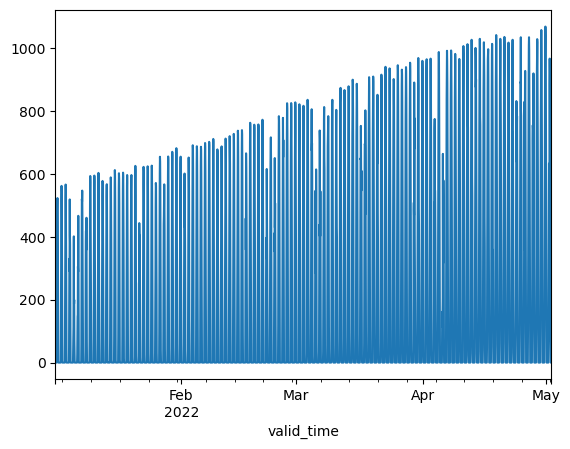

In [21]:
df['dswrf'].sort_index().plot()

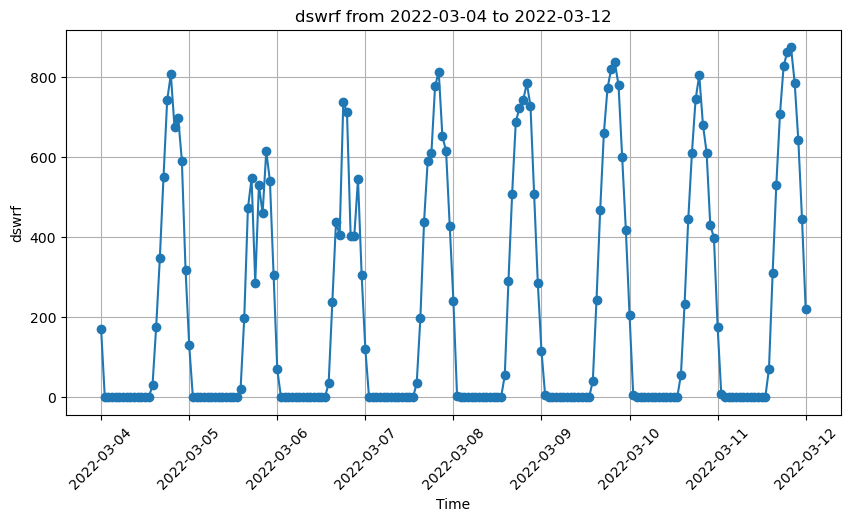

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Define date range
start_date = '2022-03-04'
end_date   = '2022-03-12'

# Subset using the index
df_subset = df[(df.index >= start_date) & (df.index <= end_date)]
df_subset = df_subset.sort_index()  # if using index
# or
df_subset = df_subset.sort_values('valid_time')  # if using reset index

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_subset.index, df_subset['dswrf'], marker='o')
plt.xlabel('Time')
plt.ylabel('dswrf')
plt.title(f'dswrf from {start_date} to {end_date}')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



# merge with measured data

In [23]:
directory_m1_qcrad = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/station-data/qcrad1long/*.cdf"
m1_qcrad = xr.open_mfdataset(
    directory_m1_qcrad,
    preprocess=lambda ds: ds[['BestEstimate_down_short_hemisp', 'down_short_diffuse_hemisp', 'zenith']]
)
m1_qcrad = m1_qcrad.compute()

In [24]:
import xarray as xr

# Make a copy of the original dataset (optional but safer)
ds = m1_qcrad.copy()

# Compute k and clip values
ds['k'] = (ds['down_short_diffuse_hemisp'].clip(min=0) /
           ds['BestEstimate_down_short_hemisp'].clip(min=0))
ds['k'] = ds['k'].clip(min=0, max=1)

# Mask k where zenith >= 90
ds['k'] = ds['k'].where(ds['zenith'] < 90, 0)


In [25]:
# Resample all variables to hourly averages
ds_hourly = ds.resample(time='1h').mean()


In [26]:
df_hourly = ds_hourly.to_dataframe()
# Rename index to match your other DataFrame
df_hourly.index.name = 'valid_time'

# Optional: reset index if you want a column instead of index
# df_hourly = df_hourly.reset_index()


In [27]:
df_merged = pd.merge(df, df_hourly, left_index=True, right_index=True, how='inner')


In [28]:
df_merged.head()

,dswrf,vbdsf,vddsf,BestEstimate_down_short_hemisp,down_short_diffuse_hemisp,zenith,k
valid_time,,,,,,,
2022-01-01 23:00:00,144.800003,778.0,33.799999,18.534573,17.994774,86.093437,0.930894
2022-01-02 01:00:00,0.000000,0.0,0.000000,0.247285,-0.859249,107.492554,0.000000
2022-01-02 05:00:00,0.000000,0.0,0.000000,-0.061878,-1.311277,152.888199,0.000000
2022-01-01 09:00:00,0.000000,0.0,0.000000,-0.388903,-0.458280,146.619965,0.000000
2022-01-01 13:00:00,0.000000,0.0,0.000000,-0.678554,0.010282,100.939705,0.000000


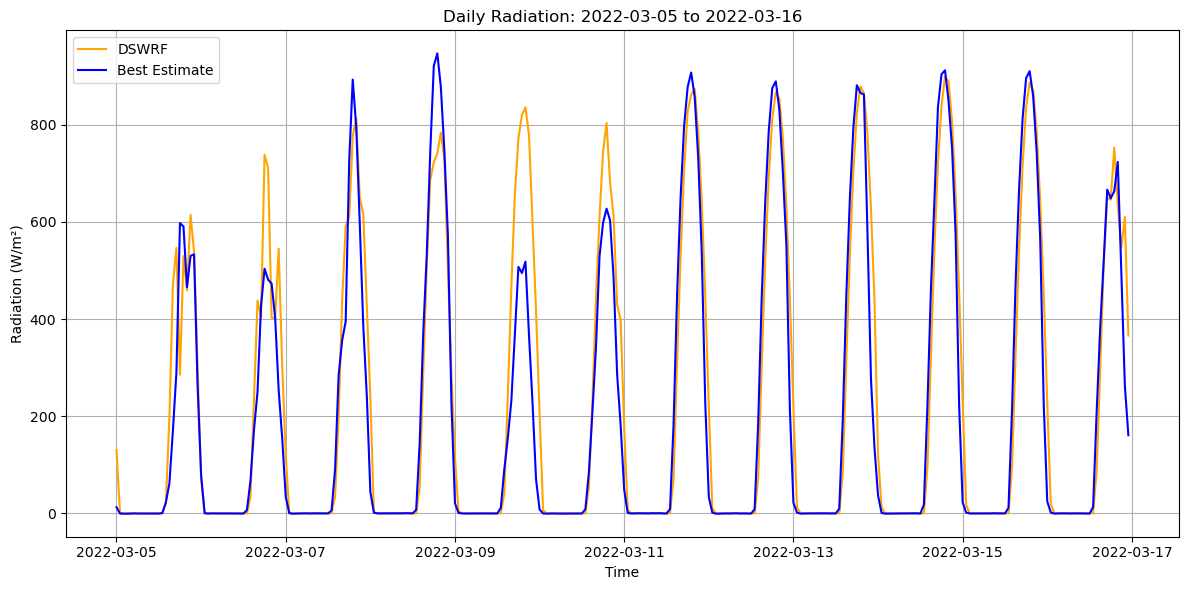

In [32]:
import matplotlib.pyplot as plt

# Ensure the index is datetime
df_merged.index = pd.to_datetime(df_merged.index)

# Sort by the index
df_merged = df_merged.sort_index()

# Now subset the week
start_date = '2022-03-05'
end_date = '2022-03-16'
df_week = df_merged.loc[start_date:end_date]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_week.index, df_week['dswrf'], label='DSWRF', color='orange')
plt.plot(df_week.index, df_week['BestEstimate_down_short_hemisp'], label='Best Estimate', color='blue')

plt.xlabel('Time')
plt.ylabel('Radiation (W/m²)')
plt.title(f'Daily Radiation: {start_date} to {end_date}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [33]:
df_merged.to_csv("df_merged_0105_2022.csv")

In [11]:
# client.close()

In [10]:
# from dask.distributed import Client

# # Start a local Dask cluster using 8 workers
# client = Client(n_workers=8, threads_per_worker=1)
# print(client)

In [ ]:
m1s = dswrf.dswrf.isel(y=iy, x=ix).compute()

import os

save_dir = 'hrrr-vars'

ds.to_netcdf(os.path.join(save_dir, 'dswrf_2022.nc'))